# Monte Carlo BDPT Munich Radiomap

This notebook loads the Sionna RT Munich Mitsuba scene through `witwin.channel.core.scene.Scene.load_mitsuba(...)` and runs the standalone Monte Carlo BDPT radio-map integrator on it.

In [1]:
from dataclasses import asdict
from pathlib import Path
import importlib
import sys
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith("witwin."):
        sys.modules.pop(module_name, None)

from witwin.channel.core.scene import ReceiverGrid, Scene, SionnaAdaptor, Transmitter
from witwin.channel.core.scene.edge_policy import EdgePolicy
from witwin.channel.core.grid import Grid
from witwin.channel.core.kernels.shadow_boundary import ShadowBoundaryKernel
from witwin.channel.montecarlo import Config, FilterConfig, IntegratorOptions, NativeExtension, Tuning, solve

display({
    "repo_root": repo_root_str,
    "native_extension_available": NativeExtension.native_extension_available(),
})

jitc_llvm_init(): LLVM API initialization failed ..


{'repo_root': 'E:\\Code\\witwin-platform\\channel',
 'native_extension_available': True}

## Scene and BDPT Configuration

In [2]:
MUNICH_XML = repo_root / "reference" / "sionna-rt-reference-2.0.1" / "src" / "sionna" / "rt" / "scenes" / "munich" / "munich.xml"
FREQUENCY_HZ = 3.5e9
TX_POS = (8.5, 21.0, 27.0)
PLANE_Z = 1.5
BOUNDS = ((-120.0, 120.0), (-120.0, 140.0))
GRID_SHAPE = (256, 256)
DIFFRACTION_SAMPLE_BUDGET = 1_000_000
REFLECTION_RAY_BUDGET = 1_000_000
SIONNA_SAMPLE_BUDGET = 1_000_000
MAX_DIFFRACTIONS = 2
SIONNA_MAX_DEPTH = 1
SCENE_DEVICE = "cuda"
WITWIN_EDGE_SELECTION_MODE = "all_edges"
WITWIN_EDGE_DIFFRACTION = True
WITWIN_BOUNDARY_EDGE_POLICY = "half_plane"
MONTE_CARLO_FILTERING = FilterConfig(
    reflection={"method": "gaussian", "radius": 1, "sigma": 0.9, "blend": 0.75},
    diffraction={"method": "bilateral", "radius": 2, "sigma": 1.25, "range_sigma": 2.0e-5, "blend": 1.0},
)


def make_bdpt_config(*, diffraction_sample_budget, reflection_ray_budget, max_diffraction_order, ad=False):
    return Config(
        num_samples=int(reflection_ray_budget),
        max_bounces=int(SIONNA_MAX_DEPTH),
        max_diffraction_order=int(max_diffraction_order),
        edge_policy=EdgePolicy(
            edge_selection_mode=WITWIN_EDGE_SELECTION_MODE,
            edge_diffraction=WITWIN_EDGE_DIFFRACTION,
            boundary_edge_policy=WITWIN_BOUNDARY_EDGE_POLICY,
        ),
        tuning=Tuning(
            enable_rd_diffraction=True,
            enable_bdpt_reflection_coupled_diffraction=False,
            shadow_boundary_mode="utd_power_smoothing",
            shadow_boundary_backend="auto",
            shadow_boundary_tile_shape=(8, 8),
            shadow_boundary_band_width_wavelengths=3.0,
            shadow_boundary_max_candidate_factor=128.0,
            diffraction_execution={"accumulate_primal": "rayd_optix"},
        ),
        integrator_options=IntegratorOptions(
            integrator="bdpt",
            samples_per_tx=int(diffraction_sample_budget),
            accumulation_backend="auto",
            seed=11,
            ad=bool(ad),
        ),
        filtering=MONTE_CARLO_FILTERING,
    )


scene = Scene.load_mitsuba(
    MUNICH_XML,
    device=SCENE_DEVICE,
    merge_shapes=True,
    frequency=FREQUENCY_HZ,
)
scene.add(Transmitter("tx", TX_POS))
grid = ReceiverGrid("rm", axis="z", position=PLANE_Z, bounds=BOUNDS, grid_shape=GRID_SHAPE)
scene.add(grid)
config = make_bdpt_config(
    diffraction_sample_budget=DIFFRACTION_SAMPLE_BUDGET,
    reflection_ray_budget=REFLECTION_RAY_BUDGET,
    max_diffraction_order=MAX_DIFFRACTIONS,
)

display({
    "scene_path": str(MUNICH_XML),
    "scene_device": scene.device,
    "structures": len(scene.structures),
    "triangles": None if scene.tri_data is None else int(scene.tri_data["n_triangles"]),
    "diffraction_edges": scene.n_diffraction_edges,
    "grid_shape": GRID_SHAPE,
    "bounds": BOUNDS,
    "tx_pos": TX_POS,
    "frequency_hz": FREQUENCY_HZ,
    "diffraction_sample_budget": DIFFRACTION_SAMPLE_BUDGET,
    "reflection_ray_budget": REFLECTION_RAY_BUDGET,
    "num_samples": config.num_samples,
    "sionna_sample_budget": SIONNA_SAMPLE_BUDGET,
    "max_bounces": config.max_bounces,
    "max_diffraction_order": config.max_diffraction_order,
    "sionna_max_depth": SIONNA_MAX_DEPTH,
    "witwin_edge_selection_mode": config.edge_policy.edge_selection_mode,
    "witwin_edge_diffraction": config.edge_policy.edge_diffraction,
    "witwin_boundary_edge_policy": config.edge_policy.boundary_edge_policy,
    "shadow_boundary_mode": config.tuning.shadow_boundary_mode,
    "shadow_boundary_backend": config.tuning.shadow_boundary_backend,
    "shadow_boundary_tile_shape": config.tuning.shadow_boundary_tile_shape,
    "shadow_boundary_band_width_wavelengths": config.tuning.shadow_boundary_band_width_wavelengths,
    "filtering": asdict(config.filtering) if config.filtering is not None else None,
    "mitsuba_metadata": scene.metadata.get("mitsuba"),
})


{'scene_path': 'E:\\Code\\witwin-platform\\channel\\reference\\sionna-rt-reference-2.0.1\\src\\sionna\\rt\\scenes\\munich\\munich.xml',
 'scene_device': 'cuda',
 'structures': 11,
 'triangles': 38936,
 'diffraction_edges': 51650,
 'grid_shape': (256, 256),
 'bounds': ((-120.0, 120.0), (-120.0, 140.0)),
 'tx_pos': (8.5, 21.0, 27.0),
 'frequency_hz': 3500000000.0,
 'diffraction_sample_budget': 1000000,
 'reflection_ray_budget': 1000000,
 'num_samples': 1000000,
 'sionna_sample_budget': 1000000,
 'max_bounces': 1,
 'max_diffraction_order': 2,
 'sionna_max_depth': 1,
 'witwin_edge_selection_mode': 'all_edges',
 'witwin_edge_diffraction': True,
 'witwin_boundary_edge_policy': 'half_plane',
 'shadow_boundary_mode': 'utd_power_smoothing',
 'shadow_boundary_backend': 'auto',
 'shadow_boundary_tile_shape': (8, 8),
 'shadow_boundary_band_width_wavelengths': 3.0,
 'filtering': {'reflection': {'method': 'gaussian',
   'radius': 1,
   'sigma': 0.9,
   'range_sigma': None,
   'blend': 0.75},
  'diff

## TX Placement Check

The transmitter coordinate is the canonical Sionna Munich tutorial coordinate. Its XY footprint overlaps the Neues Rathaus building, so it can look like it is inside the building in a top-down plot; this check verifies the 3-D placement by ray-testing around the point.


In [3]:
def _scalar_value(value):
    array = np.asarray(value)
    return float(array.reshape(-1)[0])


def _point3_values(value):
    return [_scalar_value(value[index]) for index in range(3)]


def tx_placement_check():
    rt = SionnaAdaptor.load_rt(prefer_local=True)
    mi = importlib.import_module("mitsuba")
    tx_scene = rt.load_scene(str(MUNICH_XML), merge_shapes=False)
    bbox_hits = []
    for object_name, scene_object in tx_scene.objects.items():
        bbox = scene_object.mi_mesh.bbox()
        bbox_min = [float(value) for value in bbox.min]
        bbox_max = [float(value) for value in bbox.max]
        inside_bbox = (
            bbox_min[0] <= TX_POS[0] <= bbox_max[0]
            and bbox_min[1] <= TX_POS[1] <= bbox_max[1]
            and bbox_min[2] <= TX_POS[2] <= bbox_max[2]
        )
        if inside_bbox:
            bbox_hits.append({"object": str(object_name), "bbox_min": bbox_min, "bbox_max": bbox_max})

    ray_hits = {}
    for name, direction in {
        "+z": (0.0, 0.0, 1.0),
        "-z": (0.0, 0.0, -1.0),
        "+x": (1.0, 0.0, 0.0),
        "-x": (-1.0, 0.0, 0.0),
        "+y": (0.0, 1.0, 0.0),
        "-y": (0.0, -1.0, 0.0),
    }.items():
        ray = mi.Ray3f(mi.Point3f(*TX_POS), mi.Vector3f(*direction))
        si = tx_scene.mi_scene.ray_intersect(ray)
        valid = bool(np.asarray(si.is_valid()).reshape(-1)[0])
        ray_hits[name] = None if not valid else {
            "distance_m": _scalar_value(si.t),
            "point": _point3_values(si.p),
        }

    clearance_below = None if ray_hits["-z"] is None else ray_hits["-z"]["distance_m"]
    return {
        "tx_pos": tuple(float(value) for value in TX_POS),
        "bbox_containing_tx": bbox_hits,
        "ray_hits": ray_hits,
        "roof_clearance_below_m": clearance_below,
        "placement_interpretation": (
            "Open above and about 1 m above a building surface below; this is a rooftop transmitter placement, not a sealed-volume interior point."
            if ray_hits["+z"] is None and clearance_below is not None and clearance_below <= 2.0
            else "Review the ray hits before using this transmitter position."
        ),
    }


tx_placement = tx_placement_check()
display(tx_placement)


{'tx_pos': (8.5, 21.0, 27.0),
 'bbox_containing_tx': [{'object': 'Neues_Rathaus-itu_marble',
   'bbox_min': [-57.44551467895508, -108.90657043457031, 0.0],
   'bbox_max': [79.86839294433594, 56.970558166503906, 85.0]},
  {'object': 'Neues_Rathaus-itu_metal',
   'bbox_min': [-57.44551467895508, -108.90657043457031, 0.0],
   'bbox_max': [79.86839294433594, 56.970558166503906, 63.0]}],
 'ray_hits': {'+z': None,
  '-z': {'distance_m': 1.0, 'point': [8.500000953674316, 21.0, 26.0]},
  '+x': None,
  '-x': {'distance_m': 395.5854797363281,
   'point': [-387.08544921875, 21.0, 27.0]},
  '+y': None,
  '-y': {'distance_m': 184.3910675048828,
   'point': [8.5, -163.39108276367188, 27.0]}},
 'roof_clearance_below_m': 1.0,
 'placement_interpretation': 'Open above and about 1 m above a building surface below; this is a rooftop transmitter placement, not a sealed-volume interior point.'}

## Run BDPT

In [4]:
if not NativeExtension.native_extension_available():
    raise RuntimeError("The Monte Carlo native extension is required for this BDPT example.")
if not ShadowBoundaryKernel.available():
    raise RuntimeError("Reinstall the channel_utils native extension to enable native shadow-boundary smoothing.")

result = solve(
    scene=scene,
    transmitter="tx",
    receiver="rm",
    config=config,
)

path_gain = np.asarray(result.path_gain, dtype=np.float32)
components = {
    name: np.asarray(result.incoherent[name], dtype=np.float32)
    for name in ("los", "reflection", "diffraction", "total")
}
component_summary = {}
for name, values in components.items():
    db_values = 10.0 * np.log10(np.maximum(values, 1.0e-16))
    component_summary[name] = {
        "sum": float(np.sum(values, dtype=np.float64)),
        "max": float(np.max(values)),
        "nonzero_cells": int(np.count_nonzero(values > 0.0)),
        "cells_above_-90_db": int(np.count_nonzero(db_values > -90.0)),
        "cells_above_-120_db": int(np.count_nonzero(db_values > -120.0)),
    }

shadow_boundary_stats = result.metadata["monte_carlo"]["shadow_boundary_correction"]

display({
    "path_gain_shape": path_gain.shape,
    "path_gain_min": float(np.nanmin(path_gain)),
    "path_gain_max": float(np.nanmax(path_gain)),
    "component_summary": component_summary,
    "shadow_boundary_correction": shadow_boundary_stats,
    "integrator": result.metadata["integrator"],
    "bdpt_version": result.metadata["bdpt"]["version"],
    "mis_policy": result.metadata["bdpt"]["mis_policy"],
})

{'path_gain_shape': (1, 256, 256),
 'path_gain_min': 0.0,
 'path_gain_max': 2.0071237827323785e-07,
 'component_summary': {'los': {'sum': 0.0001345754575379221,
   'max': 5.799830660180305e-08,
   'nonzero_cells': 13691,
   'cells_above_-90_db': 13691,
   'cells_above_-120_db': 13691},
  'reflection': {'sum': 4.206025262949503e-05,
   'max': 1.154107209799804e-08,
   'nonzero_cells': 16994,
   'cells_above_-90_db': 13262,
   'cells_above_-120_db': 16994},
  'diffraction': {'sum': 1.7577180950026165e-06,
   'max': 1.8832197667961736e-07,
   'nonzero_cells': 5109,
   'cells_above_-90_db': 25,
   'cells_above_-120_db': 1677},
  'total': {'sum': 0.0001666839205583662,
   'max': 2.0071237827323785e-07,
   'nonzero_cells': 19093,
   'cells_above_-90_db': 14085,
   'cells_above_-120_db': 17937}},
 'shadow_boundary_correction': {'enabled': True,
  'backend': 'native_candidate',
  'requested_backend': 'auto',
  'candidate_tiles': 49461,
  'candidate_pairs': 2386946,
  'candidate_ratio': 0.00637

## Visualize Path Gain

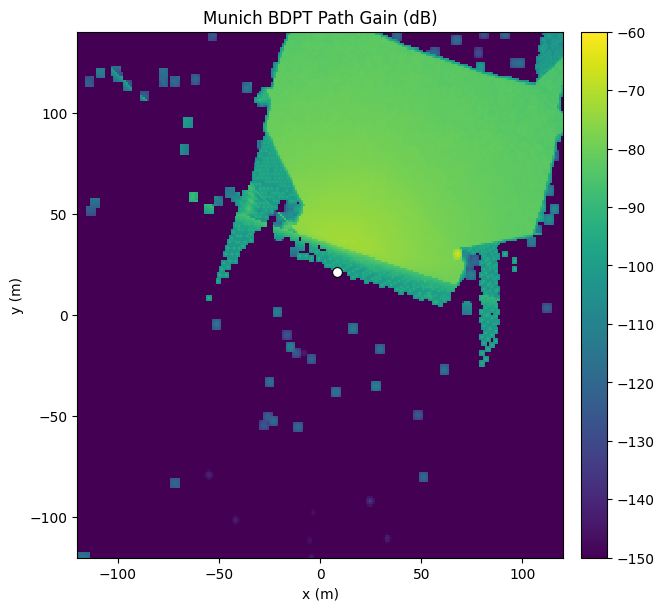

In [5]:
def path_gain_db(values, floor=1.0e-20):
    return 10.0 * np.log10(np.maximum(np.asarray(values, dtype=np.float64), float(floor)))


def map2d(values):
    array = np.asarray(values)
    if array.ndim == 3 and array.shape[0] == 1:
        return array[0]
    return array


def grid_extent(bounds):
    return (float(bounds[0][0]), float(bounds[0][1]), float(bounds[1][0]), float(bounds[1][1]))


fig, ax = plt.subplots(figsize=(7.0, 6.0), constrained_layout=True)
image = ax.imshow(
    path_gain_db(map2d(path_gain)),
    origin="lower",
    extent=grid_extent(BOUNDS),
    cmap="viridis",
    interpolation="nearest",
    vmin=-150.0,
    vmax=-60.0,
)
ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=50, edgecolors="black", linewidths=0.8)
ax.set_title("Munich BDPT Path Gain (dB)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()

## Sionna RT Comparison

This section runs Sionna RT on the same Munich XML, transmitter position, frequency, and planar radio-map grid. Sionna's `RadioMapSolver` evaluates first-order diffraction, so this is a geometry and total-power sanity comparison rather than a full reference for the BDPT `max_diffractions=2` run above.


In [6]:
def sionna_radio_map_geometry(grid_spec):
    resolved = Grid.from_spec(grid_spec)
    return resolved, {
        "center": tuple(float(value) for value in resolved.center),
        "orientation": (0.0, 0.0, 0.0),
        "size": tuple(float(value) for value in resolved.size),
        "cell_size": tuple(float(value) for value in resolved.cell_size),
        "tensor_shape": tuple(int(value) for value in resolved.tensor_shape),
    }


def make_sionna_context():
    rt = SionnaAdaptor.load_rt(prefer_local=True)
    mi = importlib.import_module("mitsuba")
    sionna_scene = rt.load_scene(str(MUNICH_XML), merge_shapes=True)
    sionna_scene.frequency = FREQUENCY_HZ
    sionna_scene.tx_array = rt.PlanarArray(
        num_rows=1,
        num_cols=1,
        pattern="iso",
        polarization="V",
    )
    sionna_scene.add(rt.Transmitter("tx", position=mi.Point3f(*TX_POS), power_dbm=0.0))
    resolved_grid, geometry = sionna_radio_map_geometry(grid)
    solver_kwargs = {
        "center": mi.Point3f(*geometry["center"]),
        "orientation": mi.Point3f(*geometry["orientation"]),
        "size": mi.Point2f(*geometry["size"]),
        "cell_size": mi.Point2f(*geometry["cell_size"]),
        "samples_per_tx": int(SIONNA_SAMPLE_BUDGET),
        "max_depth": int(SIONNA_MAX_DEPTH),
        "los": True,
        "specular_reflection": True,
        "refraction": False,
        "seed": int(config.integrator_options.seed),
    }
    return rt, mi, sionna_scene, rt.RadioMapSolver(), solver_kwargs, resolved_grid, geometry


def run_sionna_radio_map(solver, scene, solver_kwargs, *, diffraction):
    kwargs = dict(solver_kwargs)
    kwargs["diffraction"] = bool(diffraction)
    kwargs["edge_diffraction"] = bool(diffraction)
    start = time.perf_counter()
    radio_map = solver(scene, **kwargs)
    seconds = time.perf_counter() - start
    return {
        "radio_map": radio_map,
        "path_gain": np.asarray(radio_map.path_gain, dtype=np.float64)[0],
        "cell_centers": np.asarray(radio_map.cell_centers, dtype=np.float64),
        "seconds": float(seconds),
    }


rt, mi, sionna_scene, sionna_solver, sionna_kwargs, resolved_grid, sionna_geometry = make_sionna_context()
sionna_no_diff = run_sionna_radio_map(sionna_solver, sionna_scene, sionna_kwargs, diffraction=False)
sionna_with_diff = run_sionna_radio_map(sionna_solver, sionna_scene, sionna_kwargs, diffraction=True)

sionna_total = sionna_with_diff["path_gain"]
sionna_total_no_diff = sionna_no_diff["path_gain"]
sionna_diff_increment = sionna_total - sionna_total_no_diff
sionna_diff_positive = np.maximum(sionna_diff_increment, 0.0)
witwin_centers = np.stack(
    [
        np.asarray(resolved_grid.cell_centers.x, dtype=np.float64),
        np.asarray(resolved_grid.cell_centers.y, dtype=np.float64),
        np.asarray(resolved_grid.cell_centers.z, dtype=np.float64),
    ],
    axis=-1,
).reshape(resolved_grid.tensor_shape + (3,))
center_delta = witwin_centers - sionna_with_diff["cell_centers"]
max_center_delta = float(np.max(np.abs(center_delta)))
witwin_total = map2d(path_gain)
shape_match = tuple(int(value) for value in witwin_total.shape) == tuple(int(value) for value in sionna_total.shape)
if not shape_match:
    raise RuntimeError(f"Witwin/Sionna radio-map shape mismatch: {witwin_total.shape} vs {sionna_total.shape}")
if max_center_delta > 1.0e-4:
    raise RuntimeError(f"Witwin/Sionna cell centers differ by {max_center_delta:.6g} m")

witwin_db = path_gain_db(witwin_total)
sionna_db = path_gain_db(sionna_total)
delta_db = witwin_db - sionna_db
finite_delta = delta_db[np.isfinite(delta_db)]
comparison_summary = {
    "sionna_source": "sionna.rt.load_scene(..., merge_shapes=True)",
    "same_munich_xml": str(MUNICH_XML),
    "frequency_hz": float(FREQUENCY_HZ),
    "tx_pos": tuple(float(value) for value in TX_POS),
    "grid_center": sionna_geometry["center"],
    "grid_size": sionna_geometry["size"],
    "grid_cell_size": sionna_geometry["cell_size"],
    "witwin_tensor_shape": tuple(int(value) for value in witwin_total.shape),
    "sionna_tensor_shape": tuple(int(value) for value in sionna_total.shape),
    "max_cell_center_delta_m": max_center_delta,
    "sionna_samples_per_tx": int(SIONNA_SAMPLE_BUDGET),
    "sionna_max_depth": int(SIONNA_MAX_DEPTH),
    "sionna_no_diff_seconds": sionna_no_diff["seconds"],
    "sionna_with_diff_seconds": sionna_with_diff["seconds"],
    "witwin_sum": float(np.sum(witwin_total, dtype=np.float64)),
    "sionna_sum": float(np.sum(sionna_total, dtype=np.float64)),
    "witwin_minus_sionna_db_p05_p50_p95": tuple(float(value) for value in np.percentile(finite_delta, [5.0, 50.0, 95.0])),
    "sionna_diff_increment_negative_cells": int(np.count_nonzero(sionna_diff_increment < 0.0)),
    "sionna_diffraction_reference": "Sionna RadioMapSolver uses first-order diffraction; Witwin BDPT here uses max_diffractions=2.",
}
display(comparison_summary)


{'sionna_source': 'sionna.rt.load_scene(..., merge_shapes=True)',
 'same_munich_xml': 'E:\\Code\\witwin-platform\\channel\\reference\\sionna-rt-reference-2.0.1\\src\\sionna\\rt\\scenes\\munich\\munich.xml',
 'frequency_hz': 3500000000.0,
 'tx_pos': (8.5, 21.0, 27.0),
 'grid_center': (0.0, 10.0, 1.5),
 'grid_size': (240.0, 260.0),
 'grid_cell_size': (0.9375, 1.015625),
 'witwin_tensor_shape': (256, 256),
 'sionna_tensor_shape': (256, 256),
 'max_cell_center_delta_m': 0.0,
 'sionna_samples_per_tx': 1000000,
 'sionna_max_depth': 1,
 'sionna_no_diff_seconds': 0.015394899994134903,
 'sionna_with_diff_seconds': 0.06183319998672232,
 'witwin_sum': 0.0001666839205583662,
 'sionna_sum': 0.0001524610803408492,
 'witwin_minus_sionna_db_p05_p50_p95': (-1.689977943460974,
  0.0,
  50.79524273469514),
 'sionna_diff_increment_negative_cells': 1072,
 'sionna_diffraction_reference': 'Sionna RadioMapSolver uses first-order diffraction; Witwin BDPT here uses max_diffractions=2.'}

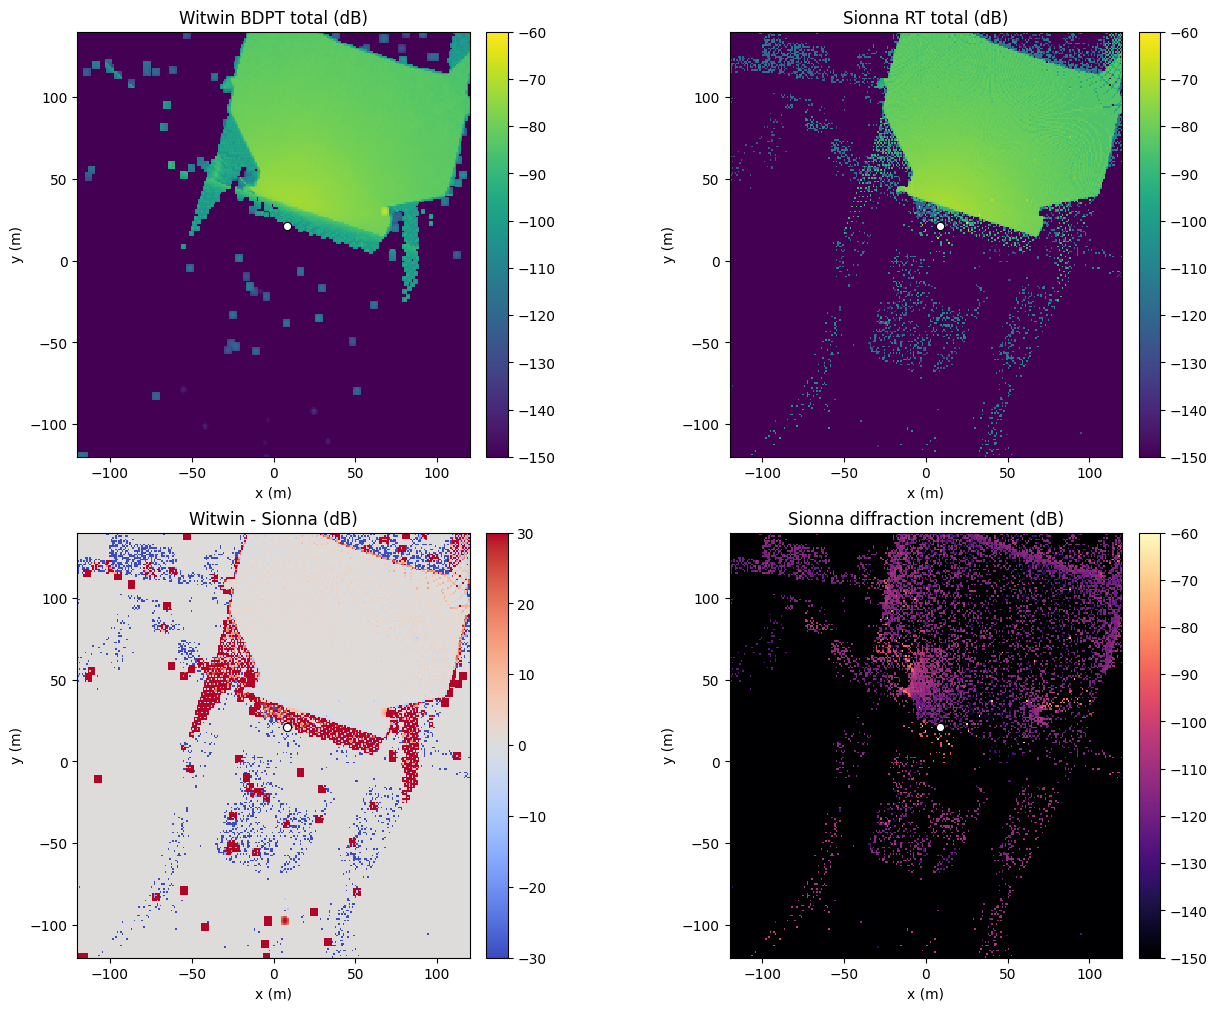

In [7]:
comparison_panels = (
    (path_gain_db(witwin_total), "Witwin BDPT total (dB)", "viridis", -150.0, -60.0),
    (path_gain_db(sionna_total), "Sionna RT total (dB)", "viridis", -150.0, -60.0),
    (delta_db, "Witwin - Sionna (dB)", "coolwarm", -30.0, 30.0),
    (path_gain_db(sionna_diff_positive), "Sionna diffraction increment (dB)", "magma", -150.0, -60.0),
)
fig, axes = plt.subplots(2, 2, figsize=(13.0, 10.0), constrained_layout=True)
for ax, (values, title, cmap, vmin, vmax) in zip(np.asarray(axes).reshape(-1), comparison_panels, strict=True):
    image = ax.imshow(
        values,
        origin="lower",
        extent=grid_extent(BOUNDS),
        cmap=cmap,
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )
    ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=35, edgecolors="black", linewidths=0.8)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()


## Component Maps

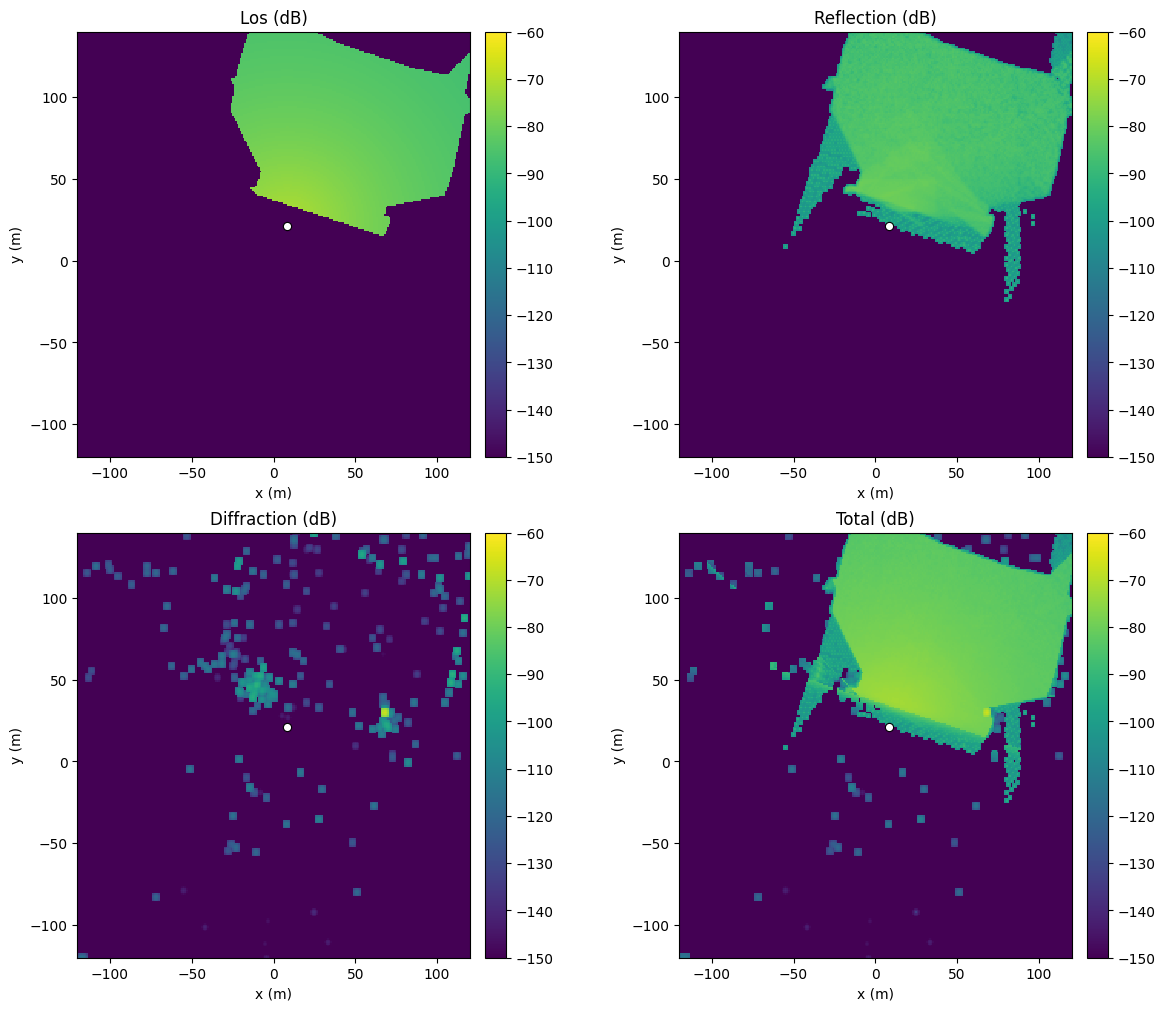

In [8]:
panel_names = ("los", "reflection", "diffraction", "total")
fig, axes = plt.subplots(2, 2, figsize=(12.0, 10.0), constrained_layout=True)
for ax, name in zip(np.asarray(axes).reshape(-1), panel_names, strict=True):
    image = ax.imshow(
        path_gain_db(map2d(components[name])),
        origin="lower",
        extent=grid_extent(BOUNDS),
        cmap="viridis",
        interpolation="nearest",
        vmin=-150.0,
        vmax=-60.0,
    )
    ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=35, edgecolors="black", linewidths=0.8)
    ax.set_title(f"{name.title()} (dB)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()